In [14]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score


class BCELabelSmoothing(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        targets_smooth = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return F.binary_cross_entropy_with_logits(logits, targets_smooth)

class Config:
    SEED = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    VAL_SIZE = 0.15
    INPUT_DIM = 2048           
    NUM_LAYERS = 1               
    EPOCHS = 20
    LEARNING_RATE = 5e-4
    WEIGHT_DECAY = 1e-2  
    EARLY_STOPPING_PATIENCE = 5
    PROJ_DIM = 256       
    HIDDEN_DIM = 64      
    NUM_LAYERS = 1       
    DROPOUT = 0.5        
    
    BATCH_SIZE = 32
    EPOCHS = 20
    LEARNING_RATE = 5e-4
    WEIGHT_DECAY = 5e-2
    
    MODEL_SAVE_PATH = "best_bilstm_attention_model.pt"


def set_seed(seed=Config.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()

# اسکن فایل‌های npy
all_npy_files = glob.glob("/kaggle/input/**/*.npy", recursive=True)

paths_0, paths_1, test_paths = [], [], []
for p in all_npy_files:
    parts = p.split(os.sep)
    if "0" in parts:
        paths_0.append(p)
    elif "1" in parts:
        paths_1.append(p)
    else:
        test_paths.append(p)

all_paths = paths_0 + paths_1
all_labels = [0] * len(paths_0) + [1] * len(paths_1)

print(f"Device: {Config.DEVICE}")
print(f"Train samples: {len(all_paths)} | Test samples: {len(test_paths)}")

Device: cuda
Train samples: 1500 | Test samples: 1344


In [15]:
class NexarFeatureDataset(Dataset):
    def __init__(self, file_paths, labels=None, is_train=False, noise_level=0.01):
        self.file_paths = file_paths
        self.labels = labels
        self.is_train = is_train
        self.noise_level = noise_level

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        feat = np.load(self.file_paths[idx])
        
        if self.is_train and self.noise_level > 0:
            feat = feat + np.random.normal(0, self.noise_level, size=feat.shape)
            
        feat_tensor = torch.tensor(feat, dtype=torch.float32)

        if self.labels is not None:
            label = torch.tensor(self.labels[idx], dtype=torch.float32)
            return feat_tensor, label
        return feat_tensor


def pad_collate_fn(batch):
    if isinstance(batch[0], tuple):
        features, labels = zip(*batch)
        lengths = torch.tensor([f.shape[0] for f in features])
        padded = nn.utils.rnn.pad_sequence(features, batch_first=True, padding_value=0.0)
        return padded, torch.stack(labels), lengths
    else:
        lengths = torch.tensor([f.shape[0] for f in batch])
        padded = nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0.0)
        return padded, lengths


class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, lstm_outputs, mask=None):
        scores = self.attn(lstm_outputs).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)
        weights = F.softmax(scores, dim=-1).unsqueeze(-1)
        context = torch.sum(lstm_outputs * weights, dim=1)
        return context, weights


class CollisionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.feat_dropout = nn.Dropout(p=0.3) # این خط اضافه شد
        
        self.feature_proj = nn.Sequential(
            nn.Linear(Config.INPUT_DIM, Config.PROJ_DIM),
            nn.LayerNorm(Config.PROJ_DIM),
            nn.ReLU(),
            nn.Dropout(Config.DROPOUT)
        )
        self.bigru = nn.GRU(
            input_size=Config.PROJ_DIM,
            hidden_size=Config.HIDDEN_DIM,
            num_layers=Config.NUM_LAYERS,
            batch_first=True,
            bidirectional=True
        )
        self.attention = TemporalAttention(Config.HIDDEN_DIM * 2)
        
        # ابعاد ورودی در 3 ضرب شد
        self.classifier = nn.Sequential(
            nn.Linear(Config.HIDDEN_DIM * 2 * 3, 64), 
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(Config.DROPOUT),
            nn.Linear(64, 1)
        )

    def forward(self, x, lengths):
        max_len = x.size(1)
        mask = torch.arange(max_len, device=x.device)[None, :] < lengths[:, None]
        
        # اعمال Dropout روی ویژگی‌های خام
        x = self.feat_dropout(x)
        x = self.feature_proj(x)
        
        # فشرده‌سازی توالی‌ها برای پردازش بهینه در LSTM
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.bigru(packed)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(
        packed_out, batch_first=True
        )
        
        # همگام‌سازی سایز ماسک با خروجی پد شده
        mask = mask[:, :lstm_out.size(1)]
        context, attn_weights = self.attention(lstm_out, mask=mask)

        # محاسبه Mean Pooling
        mask_expanded = mask.unsqueeze(-1).float()
        sum_embeddings = torch.sum(lstm_out * mask_expanded, dim=1)
        sum_mask = mask_expanded.sum(dim=1).clamp(min=1e-9)
        mean_pool = sum_embeddings / sum_mask

        # محاسبه Max Pooling
        lstm_out_masked = lstm_out.clone()
        lstm_out_masked[~mask] = -1e9
        max_pool, _ = torch.max(lstm_out_masked, dim=1)

        # ترکیب ویژگی‌ها: Attention + Mddefean + Max
        combined_features = torch.cat([context, mean_pool, max_pool], dim=1)
        
        logits = self.classifier(combined_features).squeeze(-1)
        return logits, attn_weights

In [16]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_samples = 0
    
    for x_batch, y_batch, lengths in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        lengths = lengths.to(device)
        
        optimizer.zero_grad()
        logits, _ = model(x_batch, lengths)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        batch_size = len(y_batch)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


@torch.no_grad()
def evaluate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    val_preds, val_targets = [], []
    
    for x_batch, y_batch, lengths in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        lengths = lengths.to(device)
        
        logits, _ = model(x_batch, lengths)
        loss = criterion(logits, y_batch)
        
        batch_size = len(y_batch)
        total_loss += loss.item() * batch_size
        total_samples += batch_size
        
        probs = torch.sigmoid(logits).cpu().numpy()
        val_preds.extend(probs)
        val_targets.extend(y_batch.cpu().numpy())

    val_loss = total_loss / total_samples
    val_auc = roc_auc_score(val_targets, val_preds)
    return val_loss, val_auc, val_preds, val_targets


@torch.no_grad()
def predict_loader(model, dataloader, device):
    model.eval()
    preds = []
    for x_batch, lengths in dataloader:
        x_batch = x_batch.to(device)
        lengths = lengths.to(device)
        logits, _ = model(x_batch, lengths)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds.extend(probs)
    return np.array(preds)

In [17]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=Config.VAL_SIZE, random_state=Config.SEED, stratify=all_labels
)

train_dataset = NexarFeatureDataset(train_paths, train_labels, is_train=True, noise_level=0.02)
val_dataset = NexarFeatureDataset(val_paths, val_labels, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, collate_fn=pad_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, collate_fn=pad_collate_fn)

model = CollisionClassifier().to(Config.DEVICE)
criterion = BCELabelSmoothing(smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

best_val_auc = 0.0
patience_counter = 0

print("--- Starting Baseline Training ---")

for epoch in range(1, Config.EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, Config.DEVICE)
    val_loss, val_auc, _, _ = evaluate_epoch(model, val_loader, criterion, Config.DEVICE)
    
    scheduler.step(val_auc)
    print(f"Epoch {epoch:02d}/{Config.EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), Config.MODEL_SAVE_PATH)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= Config.EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch} (Best AUC: {best_val_auc:.4f})")
            break

--- Starting Baseline Training ---
Epoch 01/20 | Train Loss: 0.6672 | Val Loss: 0.6189 | Val AUC: 0.7588
Epoch 02/20 | Train Loss: 0.6206 | Val Loss: 0.6368 | Val AUC: 0.7465
Epoch 03/20 | Train Loss: 0.5811 | Val Loss: 0.6614 | Val AUC: 0.7153
Epoch 04/20 | Train Loss: 0.5563 | Val Loss: 0.6367 | Val AUC: 0.7370
Epoch 05/20 | Train Loss: 0.5104 | Val Loss: 0.6816 | Val AUC: 0.7227
Epoch 06/20 | Train Loss: 0.4672 | Val Loss: 0.7716 | Val AUC: 0.6790
Early stopping at epoch 6 (Best AUC: 0.7588)


In [18]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=Config.SEED)

train_val_paths = np.array(all_paths)
train_val_labels = np.array(all_labels)

test_dataset = NexarFeatureDataset(test_paths)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, collate_fn=pad_collate_fn)

test_predictions_folds = np.zeros(len(test_paths))

print(f"\n--- Starting {N_SPLITS}-Fold Cross-Validation ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(train_val_paths, train_val_labels)):
    print(f"\n[Fold {fold + 1}/{N_SPLITS}]")
    
    fold_train_paths, fold_val_paths = train_val_paths[train_idx], train_val_paths[val_idx]
    fold_train_labels, fold_val_labels = train_val_labels[train_idx], train_val_labels[val_idx]
    
    train_dataset = NexarFeatureDataset(fold_train_paths, fold_train_labels, is_train=True, noise_level=0.03)
    val_dataset = NexarFeatureDataset(fold_val_paths, fold_val_labels, is_train=False)
    
    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, collate_fn=pad_collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, collate_fn=pad_collate_fn)
    
    model = CollisionClassifier().to(Config.DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=Config.WEIGHT_DECAY)
    criterion = BCELabelSmoothing(smoothing=0.1)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)
    
    best_fold_auc = 0.0
    patience_counter = 0
    fold_model_path = f"best_model_fold_{fold + 1}.pt"
    
    for epoch in range(1, Config.EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, Config.DEVICE)
        val_loss, val_auc, _, _ = evaluate_epoch(model, val_loader, criterion, Config.DEVICE)
        
        scheduler.step(val_auc)
        print(f"Fold {fold+1} | Epoch {epoch:02d}/{Config.EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

        if val_auc > best_fold_auc:
            best_fold_auc = val_auc
            torch.save(model.state_dict(), fold_model_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= Config.EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping fold {fold+1} (Best AUC: {best_fold_auc:.4f})")
                break

    # پیش‌بینی روی تست برای فولد جاری
    model.load_state_dict(torch.load(fold_model_path))
    fold_test_preds = predict_loader(model, test_loader, Config.DEVICE)
    from scipy.stats import rankdata
    
    # تبدیل احتمالات به رتبه‌های نرمال‌شده
    fold_test_preds_ranked = (rankdata(fold_test_preds) - 1) / (len(fold_test_preds) - 1)
    test_predictions_folds += fold_test_preds_ranked / N_SPLITS

print("\nEnsemble training completed.")


--- Starting 5-Fold Cross-Validation ---

[Fold 1/5]
Fold 1 | Epoch 01/20 | Train Loss: 0.6726 | Val Loss: 0.6757 | Val AUC: 0.6892
Fold 1 | Epoch 02/20 | Train Loss: 0.6077 | Val Loss: 0.7169 | Val AUC: 0.6983
Fold 1 | Epoch 03/20 | Train Loss: 0.5861 | Val Loss: 0.6905 | Val AUC: 0.7009
Fold 1 | Epoch 04/20 | Train Loss: 0.5473 | Val Loss: 0.7665 | Val AUC: 0.6793
Fold 1 | Epoch 05/20 | Train Loss: 0.5360 | Val Loss: 0.7380 | Val AUC: 0.6840
Fold 1 | Epoch 06/20 | Train Loss: 0.4935 | Val Loss: 0.8086 | Val AUC: 0.6916
Fold 1 | Epoch 07/20 | Train Loss: 0.4614 | Val Loss: 0.8265 | Val AUC: 0.6971
Fold 1 | Epoch 08/20 | Train Loss: 0.4398 | Val Loss: 0.8321 | Val AUC: 0.6735
  Early stopping fold 1 (Best AUC: 0.7009)

[Fold 2/5]
Fold 2 | Epoch 01/20 | Train Loss: 0.6758 | Val Loss: 0.6277 | Val AUC: 0.7325
Fold 2 | Epoch 02/20 | Train Loss: 0.6253 | Val Loss: 0.6221 | Val AUC: 0.7442
Fold 2 | Epoch 03/20 | Train Loss: 0.5991 | Val Loss: 0.6439 | Val AUC: 0.7380
Fold 2 | Epoch 04/20 |

Submission saved: 1344 rows.


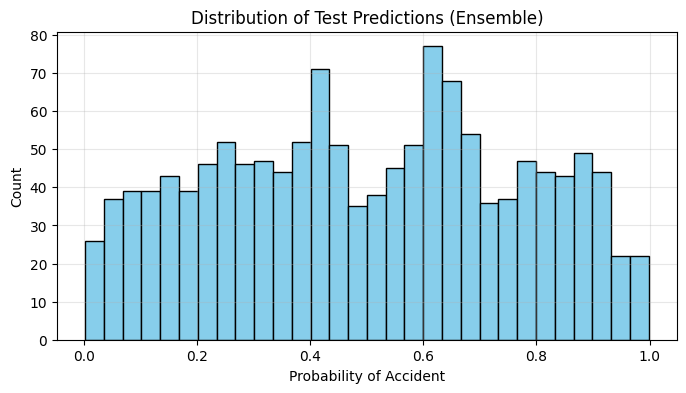

In [19]:
video_ids = [os.path.basename(p).replace(".npy", "") for p in test_paths]

submission_df = pd.DataFrame({
    "video_id": video_ids,
    "prediction": test_predictions_folds
})

submission_df.to_csv("submission.csv", index=False)
print(f"Submission saved: {len(submission_df)} rows.")

plt.figure(figsize=(8, 4))
plt.hist(submission_df['prediction'], bins=30, edgecolor='black', color='skyblue')
plt.title('Distribution of Test Predictions (Ensemble)')
plt.xlabel('Probability of Accident')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()